In [28]:
%reload_ext autoreload
%autoreload 2


In [ ]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity, MultiShellBall3StickSharedDiffusivityGammaPrior, AllGaussianAndConvolvedModels
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


sim_type = Ball3StickSharedDiffusivity#AllGaussianAndConvolvedModels#MultiShellBall3StickSharedDiffusivityGammaPrior
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

: 

In [12]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition


@jax.jit
def simulator(rng, mask_prior_hyperparameter=None):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_acquisition(rng0)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    prior_mask = sim_type.create_mask_prior()
    rng_p, rng_m = jax.random.split(rng2)
    if mask_prior_hyperparameter is  None:
        p_mask = prior_mask.sample_hyperparameters(rng_p)
    else:
        p_mask = jnp.atleast_1d(mask_prior_hyperparameter)

    # Override

    model_mask = prior_mask.sample_model_mask(rng_m, p_mask)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    data = {"acq": acq, "model_mask": model_mask, "prior_mask": p_mask, "theta": theta, "x": x_o}
    return data


In [13]:
data = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=50))

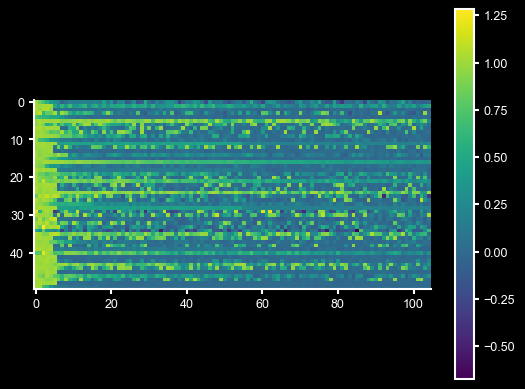

In [6]:
import matplotlib.pyplot as plt
plt.imshow(data["x"])

plt.colorbar()

In [6]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig, DMRIInferenceModelConfigMaskPriorAmortized, DMRIInferenceModelConfigMaskPriorAmortizedPPP
from dmri.nn.tokenizer import DMRITokenizerPP

cfg = DMRIInferenceModelConfigMaskPriorAmortizedPPP(sim_type, use_attention_mask=True)
cfg.theta_inference_cfg.widening_factor = 4
cfg.theta_inference_cfg.num_layers=2
cfg.model_selection_cfg.num_layers=5
cfg.model_selection_cfg.outnorm = False
cfg.model_selection_cfg.outlayer = 'mlp'  # 'linear' or 'mlp'
cfg.embedding_cfg.num_layers=2
cfg.embedding_cfg.use_global_summary_token=True
cfg.model_dim=128
model = DMRIInferenceModel(cfg, nnx.Rngs(0))

In [ ]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, _ = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated5_b3s_2_4_6_128")
graphdef, params,  state = nnx.split(model, nnx.Param,  ...)
params = checkpoint["params"]

model = nnx.merge(graphdef, params, state)
#model.eval()

In [8]:
graphdef, params, state = nnx.split(model, nnx.Param,...)


In [14]:
from dmri.train.dataset import SimulationDataset
from probjax.nn.io_util import DataLoader
dataset = SimulationDataset(simulator, rng=jax.random.PRNGKey(1), simulation_device=jax.devices("cpu")[0], simulation_batch_size=10_000, buffer_size=5_000_000)
loader = DataLoader(dataset, batch_size=4096, shuffle=True, drop_last=True)

In [15]:
dataset.get_stats()

{'batches_produced': 1,
 'production_time': 4.433327734470367,
 'samples_written': 10000,
 'batches_requested': 17,
 'samples_requested': 69632,
 'avg_production_time_per_batch': 4.433327734470367}

In [16]:


def loss_fn(params, data, rng):
    model = nnx.merge(graphdef, params,state, copy=True)
    #tokens_cfg = model.tokenizer.embed_cfgs(
    #        data["model_mask"], None,
    #    )

   # y_ctx, y = model._encode_observations(data["acq"], data["x"])
   # model_mask_loss = model.model_decoder.loss_fn(
   #         data["model_mask"],
   #         model.tokenizer,
   #         y=y,
   #         tokens_cfg=tokens_cfg,
   #         mask_prior=data["prior_mask"],
   #         additional_context=y_ctx,
   # )
    #return model_mask_loss
    loss = model.loss_fn(rng, acq=data["acq"], model_mask=data["model_mask"], mask_prior=data["prior_mask"], theta=data["theta"], x=data["x"])
    return loss[0]

@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [17]:
import optax
#scheduler = optax.cosine_onecycle_schedule(10_000, 5e-4)
optimizer = optax.radam(1e-4)
opt_state = optimizer.init(params)


In [18]:
datastream = iter(loader)
data = next(datastream)

In [19]:
key = jax.random.PRNGKey(0)

In [20]:
for step in range(10_000):
    data = next(datastream)
    key, subkey = jax.random.split(jax.random.PRNGKey(step))
    params, opt_state, loss = update(params, opt_state, data, subkey)
    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss}")
        print(dataset.get_stats())

using v loss
Step 0, Loss: 1.3457450866699219
{'batches_produced': 93, 'production_time': 4.450761244632304, 'samples_written': 930000, 'batches_requested': 20, 'samples_requested': 81920, 'avg_production_time_per_batch': 0.0478576477917452}
Step 100, Loss: 1.3440701961517334
{'batches_produced': 155, 'production_time': 4.4576163766905665, 'samples_written': 1550000, 'batches_requested': 120, 'samples_requested': 491520, 'avg_production_time_per_batch': 0.028758815333487526}
Step 200, Loss: 1.309900164604187
{'batches_produced': 163, 'production_time': 4.458454214967787, 'samples_written': 1630000, 'batches_requested': 220, 'samples_requested': 901120, 'avg_production_time_per_batch': 0.027352479846428142}
Step 300, Loss: 1.2904852628707886
{'batches_produced': 171, 'production_time': 4.459342352114618, 'samples_written': 1710000, 'batches_requested': 320, 'samples_requested': 1310720, 'avg_production_time_per_batch': 0.026078025450962678}
Step 400, Loss: 1.2939174175262451
{'batches_p

Exception ignored in: <function _xla_gc_callback at 0x155533bdcd60>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/jax/_src/lib/__init__.py", line 124, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


Step 1900, Loss: 1.110681176185608
{'batches_produced': 305, 'production_time': 4.474368709139526, 'samples_written': 3050000, 'batches_requested': 1920, 'samples_requested': 7864320, 'avg_production_time_per_batch': 0.014670061341441068}
Step 2000, Loss: 1.0812959671020508
{'batches_produced': 314, 'production_time': 4.475378949195147, 'samples_written': 3140000, 'batches_requested': 2020, 'samples_requested': 8273920, 'avg_production_time_per_batch': 0.014252799201258428}
Step 2100, Loss: 1.1437273025512695
{'batches_produced': 322, 'production_time': 4.476254656910896, 'samples_written': 3220000, 'batches_requested': 2120, 'samples_requested': 8683520, 'avg_production_time_per_batch': 0.01390141197798415}
Step 2200, Loss: 1.1038458347320557
{'batches_produced': 330, 'production_time': 4.477218118496239, 'samples_written': 3300000, 'batches_requested': 2220, 'samples_requested': 9093120, 'avg_production_time_per_batch': 0.013567327631806786}
Step 2300, Loss: 1.164098858833313
{'batch

In [ ]:
for step in range(5000):
    data = next(datastream)
    key, subkey = jax.random.split(jax.random.PRNGKey(step))
    params, opt_state, loss = update(params, opt_state, data, subkey)
    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss}")

Step 0, Loss: 1.246336579322815
Step 100, Loss: 1.225210189819336
Step 200, Loss: 1.2153985500335693
Step 300, Loss: 1.2602348327636719
Step 400, Loss: 1.2295081615447998
Step 500, Loss: 1.2335567474365234
Step 600, Loss: 1.238431453704834
Step 700, Loss: 1.223569631576538
Step 800, Loss: 1.2224284410476685
Step 900, Loss: 1.2579865455627441


KeyboardInterrupt: 

In [ ]:
for step in range(5000):
    data = next(datastream)
    key, subkey = jax.random.split(jax.random.PRNGKey(step))
    params, opt_state, loss = update(params, opt_state, data, subkey)
    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss}")

Step 0, Loss: 1.1644046306610107
Step 100, Loss: 1.1413815021514893
Step 200, Loss: 1.1564626693725586
Step 300, Loss: 1.1575865745544434
Step 400, Loss: 1.1358673572540283
Step 500, Loss: 1.1557741165161133
Step 600, Loss: 1.1721659898757935
Step 700, Loss: 1.1746729612350464
Step 800, Loss: 1.1274652481079102
Step 900, Loss: 1.155219554901123
Step 1000, Loss: 1.1504931449890137
Step 1100, Loss: 1.2033611536026
Step 1200, Loss: 1.1567519903182983
Step 1300, Loss: 1.157057523727417
Step 1400, Loss: 1.152229905128479
Step 1500, Loss: 1.1476848125457764
Step 1600, Loss: 1.1509766578674316
Step 1700, Loss: 1.1540706157684326
Step 1800, Loss: 1.1632874011993408
Step 1900, Loss: 1.14058256149292
Step 2000, Loss: 1.1321141719818115
Step 2100, Loss: 1.1480555534362793
Step 2200, Loss: 1.163061499595642
Step 2300, Loss: 1.1380678415298462
Step 2400, Loss: 1.1393892765045166
Step 2500, Loss: 1.1470885276794434
Step 2600, Loss: 1.1732999086380005
Step 2700, Loss: 1.1688761711120605
Step 2800, Lo

Exception ignored in: <function _xla_gc_callback at 0x1555338882c0>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/jax/_src/lib/__init__.py", line 124, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


Step 3600, Loss: 1.1543207168579102
Step 3700, Loss: 1.1521282196044922
Step 3800, Loss: 1.1520395278930664
Step 3900, Loss: 1.123302698135376
Step 4000, Loss: 1.1475410461425781
Step 4100, Loss: 1.133462905883789
Step 4200, Loss: 1.1434954404830933
Step 4300, Loss: 1.1254427433013916
Step 4400, Loss: 1.1496824026107788
Step 4500, Loss: 1.1463909149169922
Step 4600, Loss: 1.1483712196350098
Step 4700, Loss: 1.1408671140670776
Step 4800, Loss: 1.1594011783599854
Step 4900, Loss: 1.1403937339782715


In [21]:
model = nnx.merge(graphdef, params,state, copy=True)

In [22]:
from functools import partial
import jax
import jax.numpy as jnp
data0 = jax.vmap(partial(simulator, mask_prior_hyperparameter=jnp.array([0.1])))(jax.random.split(jax.random.PRNGKey(42), 10_000))
data1 = jax.vmap(partial(simulator, mask_prior_hyperparameter=jnp.array([0.3])))(jax.random.split(jax.random.PRNGKey(42), 10_000))
data2 = jax.vmap(partial(simulator, mask_prior_hyperparameter=jnp.array([0.5])))(jax.random.split(jax.random.PRNGKey(43), 10_000))
data3 = jax.vmap(partial(simulator, mask_prior_hyperparameter=jnp.array([0.8])))(jax.random.split(jax.random.PRNGKey(44), 10_000))

In [23]:
import jax
import jax.numpy as jnp

def log_prob_pit(data, rng, n=200):
    """
    Continuous randomized PIT from log-prob scores.

    Returns a PIT value in (0,1) that should be Uniform(0,1) under self-consistency / SBC.
    """
    rng_samp, rng_tie, rng_jit = jax.random.split(rng, 3)

    # Sample masks
    keys = jax.random.split(rng_samp, n)
    sample_fn = lambda k: model.sample_mask(
        k, acq=data["acq"], x=data["x"], mask_prior=data["prior_mask"]
    )
    masks = jax.vmap(sample_fn)(keys)

    # Log probs (force scalar)
    logprob_fn = lambda m: model.log_prob_mask(
        m, acq=data["acq"], x=data["x"], mask_prior=data["prior_mask"]
    )

    lp_true = jnp.reshape(logprob_fn(data["model_mask"]), (-1,)).sum()

    lp_samp = jax.vmap(logprob_fn)(masks)
    lp_samp = jnp.reshape(lp_samp, (n, -1)).sum(axis=1)  # shape (n,)

    # Randomized rank with tie-breaking
    eq = jnp.isclose(lp_samp, lp_true, rtol=1e-4, atol=1e-4)  # tune tolerances
    lt = (lp_samp < lp_true) & (~eq)

    n_lt = jnp.sum(lt)
    n_eq = jnp.sum(eq)

    tie = jax.random.randint(rng_tie, (), 0, n_eq + 1)   # integer in {0,...,n_eq}
    r = n_lt + tie                                       # integer rank in {0,...,n}

    # Continuous jitter within the rank cell to avoid histogram/binning artefacts
    v = jax.random.uniform(rng_jit, (), minval=0.0, maxval=1.0)
    pit = (r + v) / (n + 1)                              # in (0,1)

    return pit


def expected_coverage(data, rng, n=1000):
    """
    Returns:
      alpha: (K,) nominal levels in [0,1]
      coverage: (K,) empirical CDF of PITs, should track diagonal if calibrated
      pits: (B,) PIT values
    """
    B = data["x"].shape[0]
    keys = jax.random.split(rng, B)

    # Map across batch; data is assumed to be a pytree with leading dimension B
    pits = jax.lax.map(
        lambda args: log_prob_pit(*args, n=n),
        (data, keys),
        batch_size=100
    )

    alpha = jnp.linspace(0.0, 1.0, 101)
    coverage = jnp.mean(pits[:, None] <= alpha[None, :], axis=0)
    return alpha, coverage, pits


In [24]:
coverage0 = expected_coverage(data0, jax.random.PRNGKey(42))
coverage1 = expected_coverage(data1, jax.random.PRNGKey(0))
coverage2 = expected_coverage(data2, jax.random.PRNGKey(1))
coverage3 = expected_coverage(data3, jax.random.PRNGKey(2))

(array([ 70.,  40.,  57.,  43.,  62.,  55.,  45.,  43.,  62.,  53.,  44.,
         39.,  51.,  39.,  39.,  55.,  50.,  55.,  45.,  39.,  56.,  66.,
         51.,  50.,  49.,  46.,  50.,  59.,  53.,  40.,  54.,  44.,  52.,
         45.,  50.,  57.,  42.,  51.,  54.,  57.,  62.,  47.,  44.,  44.,
         57.,  47.,  55.,  63.,  64.,  61.,  61.,  60.,  60.,  62.,  62.,
         56.,  53.,  57.,  53.,  44.,  61.,  61.,  55.,  48.,  46.,  53.,
         44.,  29.,  62.,  47.,  46.,  64.,  55.,  38.,  50.,  56.,  66.,
         57.,  65.,  54.,  47.,  44.,  42.,  39.,  39.,  57.,  54.,  32.,
         48.,  42.,  54.,  39.,  54.,  52.,  40.,  45.,  51.,  47.,  60.,
         47.,  53.,  46.,  53.,  56.,  43.,  53.,  51.,  63.,  39.,  46.,
         37.,  46.,  49.,  50.,  46.,  43.,  42.,  41.,  52.,  43.,  49.,
         53.,  44.,  47.,  45.,  51.,  35.,  60.,  49.,  62.,  45.,  42.,
         52.,  60.,  39.,  46.,  39.,  56.,  47.,  50.,  55.,  51.,  46.,
         48.,  40.,  42.,  46.,  64., 

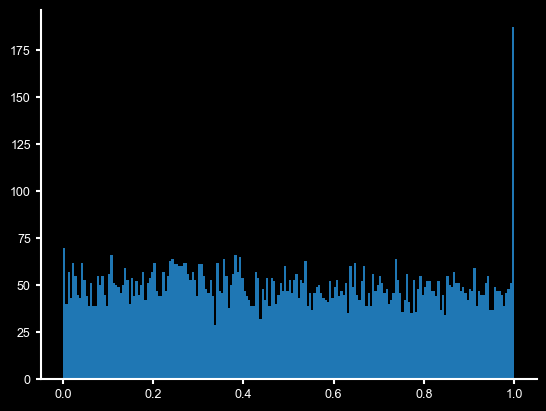

In [25]:
plt.hist(coverage0[2], bins=200)

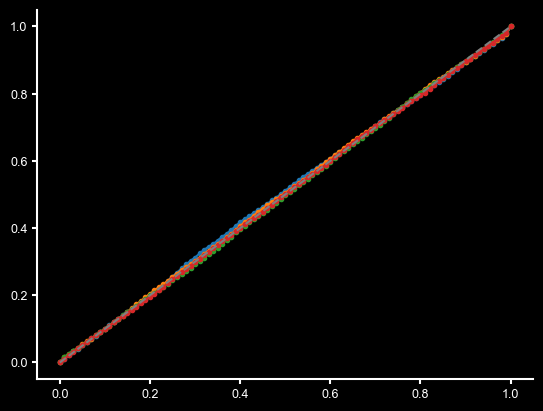

In [27]:
import matplotlib.pyplot as plt
#plt.plot(coverage[0], coverage[1], marker='o', label='Overall')
plt.plot(coverage0[0], coverage0[1], marker='o')
plt.plot(coverage1[0], coverage1[1], marker='o')
plt.plot(coverage2[0], coverage2[1], marker='o')
plt.plot(coverage3[0], coverage3[1], marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color ='gray')